# 05 Pretrained CNN Extension

This notebook is a focused pretrained-CNN extension to the engineered-feature study, not a second model benchmark or a CNN-architecture comparison.

Two prespecified configurations are evaluated: **Frozen EfficientNet Image Only** and **Frozen EfficientNet Fusion**. EfficientNet-B0 converts each fixed ROI image into a cached embedding; the fusion configuration adds ERA5, ARPA, and temporal variables under the same unweighted, date-grouped development protocol used in Notebook 4.

EfficientNet-B0 is used because ImageNet-pretrained weights are available, the model is relatively lightweight, and a frozen feature extractor limits overfitting and computational cost with the available sample size. This choice is not a claim that EfficientNet-B0 is the best CNN backbone. No other backbone and no end-to-end fine-tuning are evaluated here. The common hold-out is not used for tuning and is evaluated once after the development protocol is fixed.

**Inputs:** `data/processed/final_dataset.csv`, `data/interim/image_features.csv`, `config/roi.json`, and CV/hold-out benchmark results exported by Notebook 4

**Output:** `results/deep_learning/`

## Research Questions

**RQ4.** Can automatically learned representations from raw ROI images achieve competitive PM2.5 estimation performance compared with handcrafted image-feature methods?

**RQ5.** Does combining learned image representations with environmental and temporal predictors improve performance over raw-image representations alone?

## Workflow Overview

1. Reproduce the common split and keep the hold-out locked throughout development
2. Extract and cache frozen ImageNet-pretrained EfficientNet-B0 ROI embeddings
3. Define the shared unweighted, date-grouped training and cross-validation protocol
4. Evaluate Frozen EfficientNet Image Only
5. Evaluate Frozen EfficientNet Fusion using the same folds and training settings
6. Compare the two configurations using paired fold differences
7. Fit the final Fusion model and evaluate the common hold-out once
8. Compare EfficientNet Fusion with the all-feature models from Notebook 4


## Setup


In [79]:
import sys
import json
import importlib
from pathlib import Path

def find_project_root(start_path=None):
    """Find the nearest parent containing the project source and notebooks."""
    start = Path.cwd() if start_path is None else Path(start_path)
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root containing src/ and notebooks/."
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import src.config as config
import src.features.evaluation as evaluation
import src.deep_learning.embeddings as cnn_embeddings
import src.deep_learning.training as cnn_training
config = importlib.reload(config)
evaluation = importlib.reload(evaluation)
cnn_embeddings = importlib.reload(cnn_embeddings)
cnn_training = importlib.reload(cnn_training)

RESULTS_DIR = PROJECT_ROOT / "results" / "deep_learning"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Project root:", PROJECT_ROOT)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)


Project root: /Users/qingxuan/Desktop/webcam-pm25-toolbox
PyTorch: 2.13.0
Device: mps


## 1. Dataset and Unified Split

The same complete-case dataset and deterministic month-balanced date split used in Notebooks 3 and 4 are reproduced here.


### 1.1 Dataset and Experimental Settings

Load the processed dataset, define the shared predictors and evaluation settings, and verify that all required columns are available.


In [80]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset.csv"
IMAGE_FEATURE_PATH = PROJECT_ROOT / "data" / "interim" / "image_features.csv"
ROI_PATH = PROJECT_ROOT / "config" / "roi.json"

TARGET = config.TARGET
ALL_FEATURES = config.ALL_FEATURES
TABULAR_FEATURES = config.ERA5_FEATURES + config.ARPA_FEATURES + config.TEMPORAL_FEATURES
FINAL_TEST_SIZE = 0.20
N_SPLITS = 5
RANDOM_STATE = 42

df = pd.read_csv(DATA_PATH, parse_dates=["time"])
required_columns = ["time", TARGET, *ALL_FEATURES]
missing_columns = [column for column in required_columns if column not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

display(pd.DataFrame({
    "Item": [
        "Input dataset", "Rows loaded", "Time range",
        "Target", "Engineered predictors", "Tabular fusion predictors",
    ],
    "Value": [
        DATA_PATH.name, len(df),
        f"{df['time'].min():%Y-%m-%d %H:%M} to {df['time'].max():%Y-%m-%d %H:%M}",
        TARGET, len(ALL_FEATURES), len(TABULAR_FEATURES),
    ],
}))


,Item,Value
0,Input dataset,final_dataset.csv
1,Rows loaded,3180
2,Time range,2025-01-29 15:00 to 2026-07-20 21:00
3,Target,PM25
4,Engineered predictors,55
5,Tabular fusion predictors,37


### 1.2 Common Development and Hold-Out Split

Reproduce the deterministic month-balanced, date-disjoint split used in Notebooks 3 and 4. The common hold-out remains unavailable during model development and is evaluated once only after all training choices are fixed.


In [81]:
analysis_df = df[required_columns].dropna().sort_values("time").reset_index(drop=True)
analysis_df["date_group"] = analysis_df["time"].dt.normalize()
development_df, final_test_df = evaluation.balanced_month_group_split(
    analysis_df,
    time_column="time",
    test_size=FINAL_TEST_SIZE,
    random_state=RANDOM_STATE,
)

shared_dates = set(development_df["date_group"]) & set(final_test_df["date_group"])
if shared_dates:
    raise ValueError("Development and final test contain shared dates.")

split_summary = pd.DataFrame({
    "Subset": ["Development", "Locked final test"],
    "Samples": [len(development_df), len(final_test_df)],
    "Independent dates": [
        development_df['date_group'].nunique(),
        final_test_df['date_group'].nunique(),
    ],
})
split_summary["Percentage"] = (
    split_summary["Samples"] / len(analysis_df) * 100
)
display(split_summary.round({"Percentage": 1}))


,Subset,Samples,Independent dates,Percentage
0,Development,2544,148,80.0
1,Locked final test,636,38,20.0


### 1.3 Source-Image and ROI Linkage

Link each observation to its source webcam image, verify image availability, and load the fixed ROI definition used for frozen embedding extraction.


In [82]:
image_mapping = pd.read_csv(
    IMAGE_FEATURE_PATH,
    usecols=["datetime", "image_path"],
    parse_dates=["datetime"],
).rename(columns={"datetime": "time"})
if image_mapping["time"].duplicated().any():
    raise ValueError("Duplicate timestamps in image mapping.")

def resolve_image_path(value):
    path = Path(value)
    return path if path.is_absolute() else PROJECT_ROOT / path

image_mapping["image_path"] = image_mapping["image_path"].map(resolve_image_path)

def attach_images(data):
    linked = data.merge(image_mapping, on="time", how="left", validate="many_to_one")
    linked["image_available"] = linked["image_path"].map(
        lambda path: isinstance(path, Path) and path.is_file()
    )
    return linked

development_df = attach_images(development_df)
final_test_df = attach_images(final_test_df)

with open(ROI_PATH, "r") as file:
    ROI_CONFIG = json.load(file)

if not development_df["image_available"].all() or not final_test_df["image_available"].all():
    raise ValueError("One or more observations do not have an available source image.")

display(pd.DataFrame({
    "Subset": ["Development", "Locked final test"],
    "Images available": [
        development_df["image_available"].sum(),
        final_test_df["image_available"].sum(),
    ],
    "Images missing": [
        (~development_df["image_available"]).sum(),
        (~final_test_df["image_available"]).sum(),
    ],
}))


,Subset,Images available,Images missing
0,Development,2544,0
1,Locked final test,636,0


## 2. Frozen EfficientNet-B0 Embeddings

The ImageNet-pretrained EfficientNet-B0 backbone is frozen. Each fixed ROI is deterministically transformed into a 1280-dimensional embedding once and cached. Only development images are processed at this stage.


In [83]:
IMAGE_SIZE = 224
EMBEDDING_BATCH_SIZE = 64
DEVELOPMENT_CACHE = RESULTS_DIR / "development_efficientnet_b0_embeddings.npz"

development_embeddings, loaded_from_cache, extraction_seconds = (
    cnn_embeddings.load_or_extract_embeddings(
        development_df,
        ROI_CONFIG,
        DEVELOPMENT_CACHE,
        DEVICE,
        image_size=IMAGE_SIZE,
        batch_size=EMBEDDING_BATCH_SIZE,
    )
)

if loaded_from_cache:
    print("Loaded cached development embeddings.")
else:
    print(f"Embedding extraction time: {extraction_seconds:.1f} s")
    print("Saved:", DEVELOPMENT_CACHE)

display(pd.DataFrame({
    "Item": [
        "Development samples", "Image size", "Embedding shape",
        "Finite values", "Loaded from cache",
    ],
    "Value": [
        len(development_df), f"{IMAGE_SIZE} × {IMAGE_SIZE}",
        development_embeddings.shape,
        bool(np.isfinite(development_embeddings).all()),
        loaded_from_cache,
    ],
}))


Loaded cached development embeddings.


,Item,Value
0,Development samples,2544
1,Image size,224 × 224
2,Embedding shape,"(2544, 1280)"
3,Finite values,True
4,Loaded from cache,True


## 3. Shared Training and Cross-Validation Protocol

Both CNN configurations use the same prespecified training settings, target values, outer date-grouped folds, and training-fold internal validation procedure. Image embeddings, structured predictors, and the PM2.5 target are standardised using internal-training statistics only. Training loss and validation metrics are unweighted.


In [84]:
TRAINING_CONFIG = {
    **cnn_training.DEFAULT_TRAINING_CONFIG,
}

tabular_matrix = development_df[TABULAR_FEATURES].to_numpy(dtype=np.float32)
target_array = development_df[TARGET].to_numpy(dtype=np.float32)
outer_splits = cnn_training.build_outer_splits(
    development_df, n_splits=N_SPLITS, group_column="date_group"
)

display(pd.DataFrame({
    "Setting": [*TRAINING_CONFIG.keys(), "outer_folds", "grouping"],
    "Value": [*TRAINING_CONFIG.values(), len(outer_splits), "calendar date"],
}))

,Setting,Value
0,batch_size,64
1,maximum_epochs,150
2,early_stopping_patience,12
3,learning_rate,0.001
4,weight_decay,0.0001
5,dropout,0.3
6,internal_validation_size,0.15
7,outer_folds,5
8,grouping,calendar date


## 4. Frozen EfficientNet Image Only

The image-only regression head uses cached EfficientNet-B0 embeddings without environmental or temporal predictors. This configuration tests whether automatically learned raw-ROI representations contain useful PM2.5 information on their own.


### 4.1 Image-Only Development Cross-Validation

Train and evaluate the image-only configuration using the shared unweighted, date-grouped development protocol.


In [85]:
image_only_outputs = cnn_training.train_image_only_cross_validation(
    data=development_df,
    embeddings=development_embeddings,
    targets=target_array,
    outer_splits=outer_splits,
    device=DEVICE,
    config=TRAINING_CONFIG,
    random_state=RANDOM_STATE,
)


Image-only fold 1 | Epoch 001 | Internal RMSE 7.505 | Best epoch 1
Image-only fold 1 | Epoch 010 | Internal RMSE 7.170 | Best epoch 8
Image-only fold 1 | Epoch 020 | Internal RMSE 7.425 | Best epoch 8
Image-only fold 1 completed | Best epoch 8 | Outer R2 0.637 | 2.6 s
Image-only fold 2 | Epoch 001 | Internal RMSE 6.763 | Best epoch 1
Image-only fold 2 | Epoch 010 | Internal RMSE 6.575 | Best epoch 9
Image-only fold 2 | Epoch 020 | Internal RMSE 6.617 | Best epoch 9
Image-only fold 2 completed | Best epoch 9 | Outer R2 0.771 | 2.7 s
Image-only fold 3 | Epoch 001 | Internal RMSE 6.626 | Best epoch 1
Image-only fold 3 | Epoch 010 | Internal RMSE 6.487 | Best epoch 9
Image-only fold 3 | Epoch 020 | Internal RMSE 6.617 | Best epoch 9
Image-only fold 3 completed | Best epoch 9 | Outer R2 0.740 | 5.3 s
Image-only fold 4 | Epoch 001 | Internal RMSE 7.466 | Best epoch 1
Image-only fold 4 | Epoch 010 | Internal RMSE 7.774 | Best epoch 1
Image-only fold 4 completed | Best epoch 1 | Outer R2 0.654

In [86]:
image_only_fold_results = pd.DataFrame([
    {
        "Fold": fold_number,
        "MAE": output["metrics"]["MAE"],
        "RMSE": output["metrics"]["RMSE"],
        "R2": output["metrics"]["R2"],
        "Best Epoch": output["best_epoch"],
        "Train Time (s)": output["training_time"],
    }
    for fold_number, output in enumerate(image_only_outputs, start=1)
])

image_only_cv_result = pd.DataFrame([{
    "Model": "Frozen EfficientNet Image Only",
    "Feature Set": "Raw ROI embedding",
    "Variables": development_embeddings.shape[1],
    "CV MAE": image_only_fold_results["MAE"].mean(),
    "CV MAE Std": image_only_fold_results["MAE"].std(),
    "CV RMSE": image_only_fold_results["RMSE"].mean(),
    "CV RMSE Std": image_only_fold_results["RMSE"].std(),
    "CV R2": image_only_fold_results["R2"].mean(),
    "CV R2 Std": image_only_fold_results["R2"].std(),
}])

display(image_only_fold_results.round(3))
display(image_only_cv_result[[
    "Model", "CV MAE", "CV MAE Std", "CV RMSE",
    "CV RMSE Std", "CV R2", "CV R2 Std",
]].round(3))

image_only_fold_results.to_csv(
    RESULTS_DIR / "image_only_cnn_fold_results.csv", index=False
)


,Fold,MAE,RMSE,R2,Best Epoch,Train Time (s)
0,1,5.197,6.862,0.637,8,2.602
1,2,4.527,6.490,0.771,9,2.714
2,3,4.517,6.124,0.740,9,5.252
3,4,5.458,7.962,0.654,1,3.114
4,5,4.847,6.996,0.634,10,2.997


,Model,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R2,CV R2 Std
0,Frozen EfficientNet Image Only,4.91,0.415,6.887,0.691,0.687,0.064


### 4.2 Image-Only Early-Stopping Diagnostic

Internal-validation RMSE is shown for each image-only outer fold, with the selected best epoch marked on each curve.


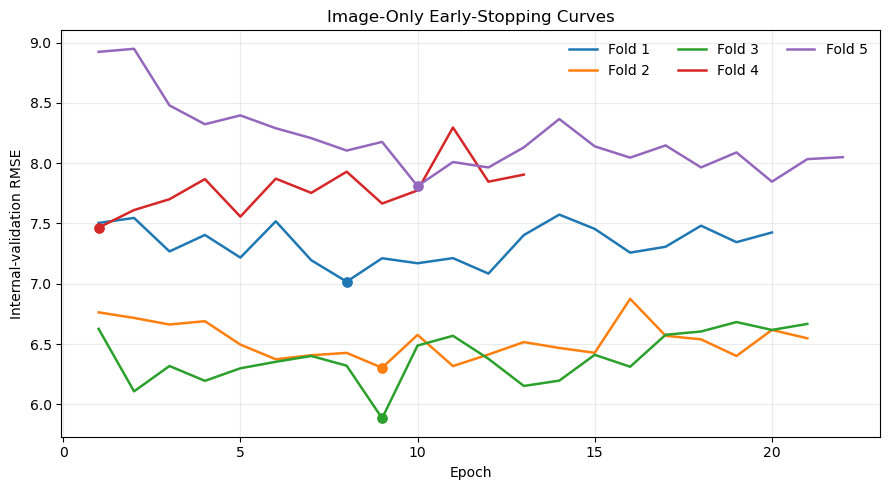

In [87]:
fig, ax = plt.subplots(figsize=(9, 5))

for fold_number, output in enumerate(image_only_outputs, start=1):
    history = output["history"]
    line = ax.plot(
        history["Epoch"],
        history["Internal validation RMSE"],
        label=f"Fold {fold_number}",
        linewidth=1.8,
    )[0]
    best_row = history.loc[history["Epoch"] == output["best_epoch"]].iloc[0]
    ax.scatter(
        best_row["Epoch"],
        best_row["Internal validation RMSE"],
        color=line.get_color(),
        s=45,
        zorder=3,
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Internal-validation RMSE")
ax.set_title("Image-Only Early-Stopping Curves")
ax.grid(alpha=0.25)
ax.legend(ncol=3, frameon=False)
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "image_only_early_stopping_curves.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 5. Frozen EfficientNet Fusion

The fusion regression head combines each cached 1280-dimensional ROI embedding with the 37 ERA5, ARPA, and temporal predictors. Its comparison with Image Only tests whether structured predictors add value beyond learned raw-image representations.


### 5.1 Fusion Development Cross-Validation

Train and evaluate Fusion using exactly the same outer folds, internal validation procedure, and training settings as Image Only.


In [88]:
cnn_fold_outputs = cnn_training.train_fusion_cross_validation(
    data=development_df,
    embeddings=development_embeddings,
    tabular_values=tabular_matrix,
    targets=target_array,
    outer_splits=outer_splits,
    device=DEVICE,
    config=TRAINING_CONFIG,
    random_state=RANDOM_STATE,
)


Fusion fold 1 | Epoch 001 | Internal RMSE 7.549 | Best epoch 1
Fusion fold 1 | Epoch 010 | Internal RMSE 6.642 | Best epoch 5
Fusion fold 1 completed | Best epoch 5 | Outer R2 0.718 | 3.3 s
Fusion fold 2 | Epoch 001 | Internal RMSE 6.501 | Best epoch 1
Fusion fold 2 | Epoch 010 | Internal RMSE 5.765 | Best epoch 6
Fusion fold 2 | Epoch 020 | Internal RMSE 5.578 | Best epoch 12
Fusion fold 2 completed | Best epoch 12 | Outer R2 0.810 | 4.4 s
Fusion fold 3 | Epoch 001 | Internal RMSE 6.798 | Best epoch 1
Fusion fold 3 | Epoch 010 | Internal RMSE 5.962 | Best epoch 9
Fusion fold 3 | Epoch 020 | Internal RMSE 5.665 | Best epoch 9
Fusion fold 3 completed | Best epoch 9 | Outer R2 0.770 | 3.6 s
Fusion fold 4 | Epoch 001 | Internal RMSE 7.461 | Best epoch 1
Fusion fold 4 | Epoch 010 | Internal RMSE 7.183 | Best epoch 8
Fusion fold 4 | Epoch 020 | Internal RMSE 7.334 | Best epoch 12
Fusion fold 4 completed | Best epoch 12 | Outer R2 0.774 | 6.1 s
Fusion fold 5 | Epoch 001 | Internal RMSE 8.468

In [89]:
cnn_fold_results = pd.DataFrame([
    {
        "Fold": fold_number,
        "MAE": output["metrics"]["MAE"],
        "RMSE": output["metrics"]["RMSE"],
        "R2": output["metrics"]["R2"],
        "Best Epoch": output["best_epoch"],
        "Train Time (s)": output["training_time"],
    }
    for fold_number, output in enumerate(cnn_fold_outputs, start=1)
])

cnn_cv_result = pd.DataFrame([{
    "Model": "Frozen EfficientNet Fusion",
    "Feature Set": "Raw ROI embedding + environmental features",
    "Variables": development_embeddings.shape[1] + len(TABULAR_FEATURES),
    "CV MAE": cnn_fold_results["MAE"].mean(),
    "CV MAE Std": cnn_fold_results["MAE"].std(),
    "CV RMSE": cnn_fold_results["RMSE"].mean(),
    "CV RMSE Std": cnn_fold_results["RMSE"].std(),
    "CV R2": cnn_fold_results["R2"].mean(),
    "CV R2 Std": cnn_fold_results["R2"].std(),
}])

display(cnn_fold_results.round(3))
display(cnn_cv_result[[
    "Model", "CV MAE", "CV MAE Std", "CV RMSE",
    "CV RMSE Std", "CV R2", "CV R2 Std",
]].round(3))

cnn_fold_results.to_csv(RESULTS_DIR / "cnn_fold_results.csv", index=False)
cnn_cv_result.to_csv(RESULTS_DIR / "cnn_cv_result.csv", index=False)


,Fold,MAE,RMSE,R2,Best Epoch,Train Time (s)
0,1,4.626,6.049,0.718,5,3.309
1,2,4.364,5.916,0.810,12,4.356
2,3,4.343,5.770,0.770,9,3.635
3,4,4.845,6.430,0.774,12,6.051
4,5,4.793,6.874,0.646,15,9.582


,Model,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R2,CV R2 Std
0,Frozen EfficientNet Fusion,4.594,0.234,6.208,0.446,0.744,0.063


### 5.2 Fusion Early-Stopping Diagnostic

Internal-validation RMSE is shown for each fusion outer fold. The marked epoch is selected without consulting the outer validation fold or common hold-out.


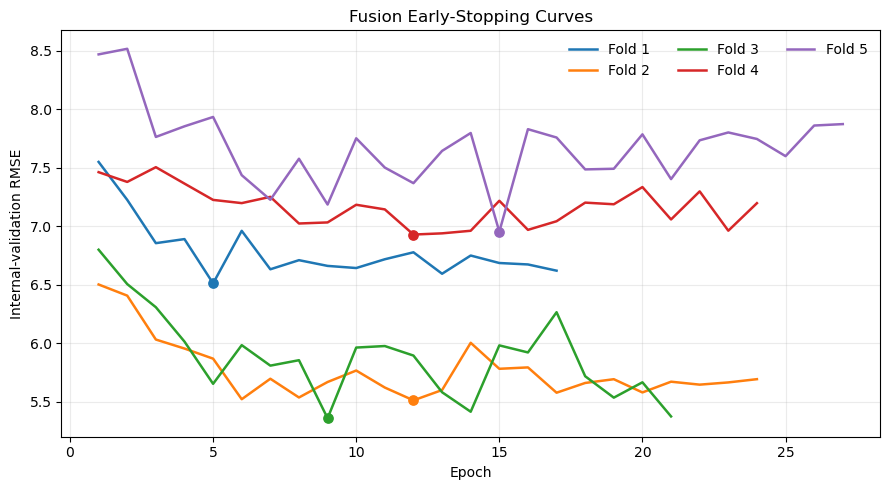

In [90]:
fig, ax = plt.subplots(figsize=(9, 5))

for fold_number, output in enumerate(cnn_fold_outputs, start=1):
    history = output["history"]
    line = ax.plot(
        history["Epoch"],
        history["Internal validation RMSE"],
        label=f"Fold {fold_number}",
        linewidth=1.8,
    )[0]
    best_row = history.loc[history["Epoch"] == output["best_epoch"]].iloc[0]
    ax.scatter(
        best_row["Epoch"],
        best_row["Internal validation RMSE"],
        color=line.get_color(),
        s=45,
        zorder=3,
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Internal-validation RMSE")
ax.set_title("Fusion Early-Stopping Curves")
ax.grid(alpha=0.25)
ax.legend(ncol=3, frameon=False)
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "fusion_early_stopping_curves.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 6. Comparative Evaluation

### 6.1 Paired Image-Only–Fusion Comparison

Because both configurations use identical outer folds, fold-level paired differences quantify whether Fusion consistently improves over Image Only. Positive values indicate improvement for all three reported differences.


In [91]:
paired_fold_results = image_only_fold_results[[
    "Fold", "MAE", "RMSE", "R2",
]].merge(
    cnn_fold_results[["Fold", "MAE", "RMSE", "R2"]],
    on="Fold",
    suffixes=(" Image Only", " Fusion"),
    validate="one_to_one",
)

paired_fold_results["MAE Reduction"] = (
    paired_fold_results["MAE Image Only"] - paired_fold_results["MAE Fusion"]
)
paired_fold_results["RMSE Reduction"] = (
    paired_fold_results["RMSE Image Only"] - paired_fold_results["RMSE Fusion"]
)
paired_fold_results["R2 Gain"] = (
    paired_fold_results["R2 Fusion"] - paired_fold_results["R2 Image Only"]
)

paired_summary = pd.DataFrame([
    {
        "Metric": metric,
        "Mean paired improvement": paired_fold_results[metric].mean(),
        "Std paired improvement": paired_fold_results[metric].std(),
        "Improved folds": int((paired_fold_results[metric] > 0).sum()),
        "Total folds": len(paired_fold_results),
    }
    for metric in ["MAE Reduction", "RMSE Reduction", "R2 Gain"]
])

cnn_configuration_results = pd.concat(
    [image_only_cv_result, cnn_cv_result], ignore_index=True
)

display(paired_fold_results.round(3))
display(paired_summary.round(3))
display(cnn_configuration_results[[
    "Model", "CV MAE", "CV MAE Std", "CV RMSE",
    "CV RMSE Std", "CV R2", "CV R2 Std",
]].round(3))

paired_fold_results.to_csv(
    RESULTS_DIR / "paired_configuration_fold_results.csv", index=False
)
paired_summary.to_csv(
    RESULTS_DIR / "paired_configuration_summary.csv", index=False
)
cnn_configuration_results.to_csv(
    RESULTS_DIR / "cnn_configuration_results.csv", index=False
)


,Fold,MAE Image Only,RMSE Image Only,R2 Image Only,MAE Fusion,RMSE Fusion,R2 Fusion,MAE Reduction,RMSE Reduction,R2 Gain
0,1,5.197,6.862,0.637,4.626,6.049,0.718,0.571,0.813,0.081
1,2,4.527,6.490,0.771,4.364,5.916,0.810,0.164,0.575,0.039
2,3,4.517,6.124,0.740,4.343,5.770,0.770,0.174,0.354,0.029
3,4,5.458,7.962,0.654,4.845,6.430,0.774,0.613,1.531,0.120
4,5,4.847,6.996,0.634,4.793,6.874,0.646,0.054,0.123,0.013


,Metric,Mean paired improvement,Std paired improvement,Improved folds,Total folds
0,MAE Reduction,0.315,0.258,5,5
1,RMSE Reduction,0.679,0.541,5,5
2,R2 Gain,0.056,0.044,5,5


,Model,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R2,CV R2 Std
0,Frozen EfficientNet Image Only,4.910,0.415,6.887,0.691,0.687,0.064
1,Frozen EfficientNet Fusion,4.594,0.234,6.208,0.446,0.744,0.063


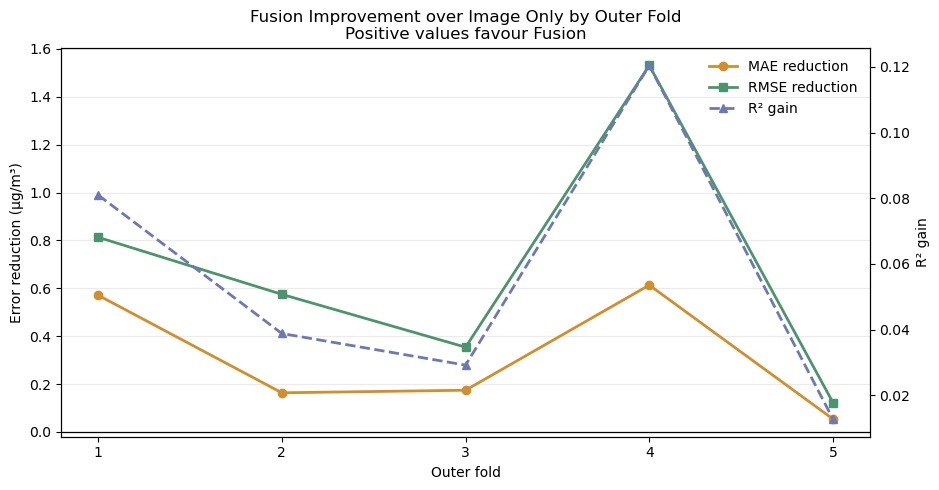

In [97]:
folds = paired_fold_results["Fold"]

fig, left_ax = plt.subplots(figsize=(9.5, 5))
right_ax = left_ax.twinx()

mae_line = left_ax.plot(
    folds,
    paired_fold_results["MAE Reduction"],
    marker="o",
    linewidth=2,
    color="#D28E2D",
    label="MAE reduction",
)
rmse_line = left_ax.plot(
    folds,
    paired_fold_results["RMSE Reduction"],
    marker="s",
    linewidth=2,
    color="#4C956C",
    label="RMSE reduction",
)
r2_line = right_ax.plot(
    folds,
    paired_fold_results["R2 Gain"],
    marker="^",
    linewidth=2,
    linestyle="--",
    color="#6D78B4",
    label="R² gain",
)

left_ax.axhline(0, color="black", linewidth=0.9)
left_ax.set_xticks(folds)
left_ax.set_xlabel("Outer fold")
left_ax.set_ylabel("Error reduction (µg/m³)")
right_ax.set_ylabel("R² gain")
left_ax.set_title(
    "Fusion Improvement over Image Only by Outer Fold\n"
    "Positive values favour Fusion"
)
left_ax.grid(axis="y", alpha=0.25)

all_lines = mae_line + rmse_line + r2_line
left_ax.legend(
    all_lines,
    [line.get_label() for line in all_lines],
    frameon=False,
    loc="upper right",
)

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "paired_configuration_improvements.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


### 6.2 Common Hold-Out and All-Feature Model Comparison

The final Fusion training duration is fixed as the median best epoch from development CV, then the model is refitted on all development observations and evaluated once on the common hold-out. Its CV and test metrics are compared with the five all-feature models from Notebook 4.


In [93]:
HOLDOUT_CACHE = RESULTS_DIR / "holdout_efficientnet_b0_embeddings.npz"
holdout_embeddings, holdout_loaded_from_cache, holdout_extraction_seconds = (
    cnn_embeddings.load_or_extract_embeddings(
        final_test_df,
        ROI_CONFIG,
        HOLDOUT_CACHE,
        DEVICE,
        image_size=IMAGE_SIZE,
        batch_size=EMBEDDING_BATCH_SIZE,
    )
)

if holdout_loaded_from_cache:
    print("Loaded cached hold-out embeddings.")
else:
    print(f"Hold-out embedding extraction time: {holdout_extraction_seconds:.1f} s")
    print("Saved:", HOLDOUT_CACHE)

display(pd.DataFrame({
    "Item": ["Hold-out samples", "Embedding shape", "Loaded from cache"],
    "Value": [
        len(final_test_df),
        holdout_embeddings.shape,
        holdout_loaded_from_cache,
    ],
}))


Loaded cached hold-out embeddings.


,Item,Value
0,Hold-out samples,636
1,Embedding shape,"(636, 1280)"
2,Loaded from cache,True


In [94]:
FINAL_FUSION_EPOCHS = int(
    np.median(cnn_fold_results["Best Epoch"]).round()
)
holdout_tabular_matrix = final_test_df[TABULAR_FEATURES].to_numpy(
    dtype=np.float32
)
holdout_target_array = final_test_df[TARGET].to_numpy(dtype=np.float32)

fusion_holdout_output = cnn_training.fit_and_evaluate_fusion_holdout(
    development_embeddings=development_embeddings,
    development_tabular=tabular_matrix,
    development_targets=target_array,
    holdout_embeddings=holdout_embeddings,
    holdout_tabular=holdout_tabular_matrix,
    holdout_targets=holdout_target_array,
    device=DEVICE,
    epochs=FINAL_FUSION_EPOCHS,
    config=TRAINING_CONFIG,
    random_state=RANDOM_STATE,
)

fusion_benchmark_result = cnn_cv_result.copy()
fusion_benchmark_result["Model"] = "EfficientNet Fusion"
fusion_benchmark_result["Test MAE"] = fusion_holdout_output["metrics"]["MAE"]
fusion_benchmark_result["Test RMSE"] = fusion_holdout_output["metrics"]["RMSE"]
fusion_benchmark_result["Test R2"] = fusion_holdout_output["metrics"]["R2"]
fusion_benchmark_result["Train Time (s)"] = fusion_holdout_output["training_time"]
fusion_benchmark_result["Predict Time (s)"] = fusion_holdout_output["prediction_time"]

fusion_holdout_predictions = pd.DataFrame({
    "time": final_test_df["time"].to_numpy(),
    "Observed": fusion_holdout_output["observed"],
    "Predicted": fusion_holdout_output["predictions"],
})
fusion_holdout_predictions["Residual"] = (
    fusion_holdout_predictions["Observed"]
    - fusion_holdout_predictions["Predicted"]
)

display(pd.DataFrame({
    "Item": [
        "Final epochs", "Test MAE", "Test RMSE", "Test R²",
    ],
    "Value": [
        FINAL_FUSION_EPOCHS,
        fusion_holdout_output["metrics"]["MAE"],
        fusion_holdout_output["metrics"]["RMSE"],
        fusion_holdout_output["metrics"]["R2"],
    ],
}).round(3))

fusion_holdout_predictions.to_csv(
    RESULTS_DIR / "fusion_holdout_predictions.csv", index=False
)


,Item,Value
0,Final epochs,12.000
1,Test MAE,4.614
2,Test RMSE,6.295
3,Test R²,0.548


In [95]:
BENCHMARK_RESULTS_PATH = (
    PROJECT_ROOT / "results" / "model_benchmark"
    / "traditional_model_benchmark_results.csv"
)

if not BENCHMARK_RESULTS_PATH.exists():
    raise FileNotFoundError(
        "Run Notebook 4 through its common-hold-out export cell first."
    )

traditional_results = pd.read_csv(BENCHMARK_RESULTS_PATH)
traditional_context = traditional_results.copy()
traditional_context["Category"] = np.where(
    traditional_context["Model"] == "MLP",
    "Feature-based DNN",
    "Conventional ML",
)
traditional_context["Image Representation"] = "Handcrafted ROI"

fusion_context = fusion_benchmark_result.copy()
fusion_context["Category"] = "Pretrained CNN extension"
fusion_context["Image Representation"] = "Learned raw-ROI representation"

all_feature_comparison = pd.concat(
    [traditional_context, fusion_context],
    ignore_index=True,
    sort=False,
)

comparison_columns = [
    "Model", "Category", "Image Representation",
    "CV MAE", "CV RMSE", "CV R2",
    "Test MAE", "Test RMSE", "Test R2",
]
display(
    all_feature_comparison[comparison_columns]
    .rename(columns={"CV R2": "CV R²", "Test R2": "Test R²"})
    .round(3)
)

all_feature_comparison.to_csv(
    RESULTS_DIR / "development_model_comparison.csv",
    index=False,
)


,Model,Category,Image Representation,CV MAE,CV RMSE,CV R²,Test MAE,Test RMSE,Test R²
0,Ridge,Conventional ML,Handcrafted ROI,5.262,6.987,0.678,4.929,6.727,0.484
1,Decision Tree,Conventional ML,Handcrafted ROI,5.517,7.874,0.597,5.904,8.211,0.231
2,Random Forest,Conventional ML,Handcrafted ROI,4.760,6.627,0.712,4.910,6.510,0.516
3,Gradient Boosting,Conventional ML,Handcrafted ROI,4.339,5.964,0.765,4.288,5.670,0.633
4,MLP,Feature-based DNN,Handcrafted ROI,5.023,6.867,0.686,5.002,6.840,0.466
5,EfficientNet Fusion,Pretrained CNN extension,Learned raw-ROI representation,4.594,6.208,0.744,4.614,6.295,0.548


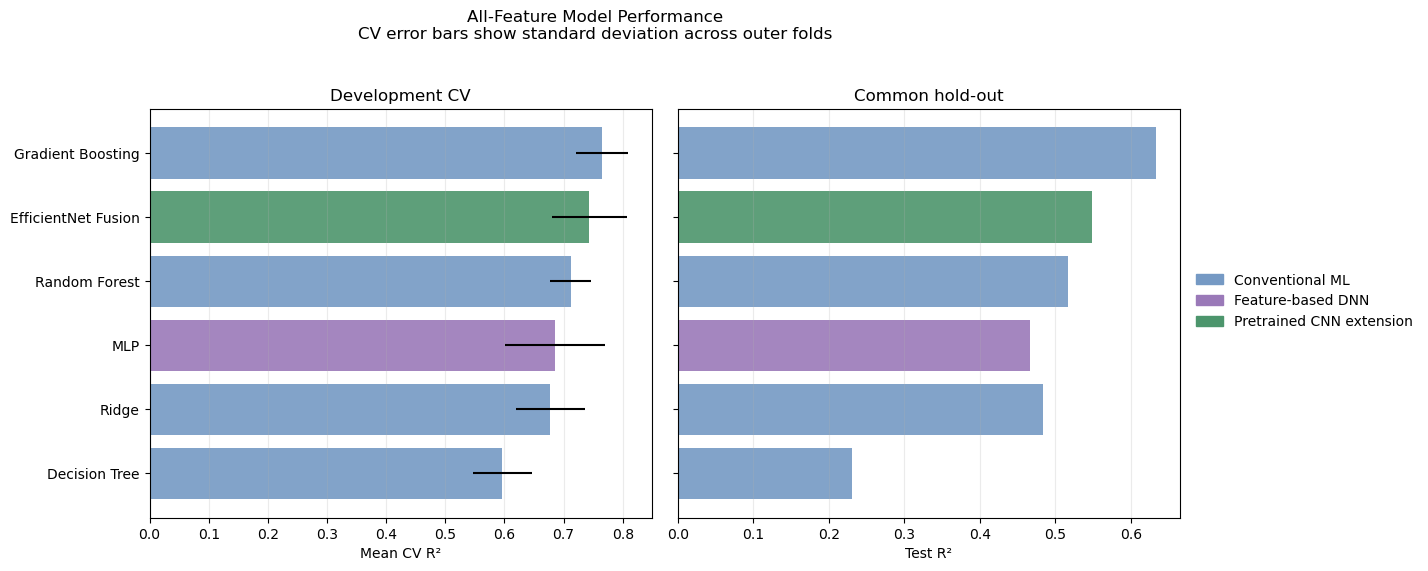

In [96]:
category_colors = {
    "Conventional ML": "#7599C4",
    "Feature-based DNN": "#9A79B8",
    "Pretrained CNN extension": "#4C956C",
}

plot_data = all_feature_comparison.sort_values("CV R2").reset_index(drop=True)
bar_colors = plot_data["Category"].map(category_colors)
y_positions = np.arange(len(plot_data))

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5.5),
    sharey=True,
)

axes[0].barh(
    y_positions,
    plot_data["CV R2"],
    xerr=plot_data["CV R2 Std"],
    color=bar_colors,
    alpha=0.9,
)
axes[0].set_title("Development CV")
axes[0].set_xlabel("Mean CV R²")
axes[0].set_yticks(y_positions)
axes[0].set_yticklabels(plot_data["Model"])
axes[0].grid(axis="x", alpha=0.25)

axes[1].barh(
    y_positions,
    plot_data["Test R2"],
    color=bar_colors,
    alpha=0.9,
)
axes[1].set_title("Common hold-out")
axes[1].set_xlabel("Test R²")
axes[1].grid(axis="x", alpha=0.25)

fig.suptitle(
    "All-Feature Model Performance\n"
    "CV error bars show standard deviation across outer folds",
    y=1.03,
)
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=color, label=category)
    for category, color in category_colors.items()
]
fig.legend(
    handles=legend_handles,
    frameon=False,
    loc="center left",
    bbox_to_anchor=(0.99, 0.5),
)

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "development_model_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()
